# Learning XOR with Multi-Layer Perceptron

In [ ]:
# TODO: measure vanishing gradients across layers
# TODO: Add decision boundary visualization: Plot the 2D input space and show how the model classifies each point.
# TODO: Show predictions table: Display all 4 XOR inputs with predictions and ground truth.
# TODO: Visualize model architecture: Use a diagram or summary of the network structure.
# TODO: Add confusion matrix: Even for 4 samples, it helps verify correctness.
# TODO: Better initialization: The Kaiming init uses a=math.sqrt(5), which is unusual; verify or use standard values.
# TODO: Loss function: MSE is used; consider BCE for binary classification
# TODO: Learning rate scheduling: Add a scheduler or learning rate decay.
# TODO: add early stopping

In [405]:
CONFIG = {
    "seed" : 42,
    "n_layers" : 2,
    "n_hidden" : 2,
    "nonlinearity" : "tanh",
    "init": "kaiming",
    "dataset" : "xor", # and, or, xor (xor requries n_layers>=2 with n_hidden>=2)
    "batch_size" : 4,
    "n_epochs" : 500,
    "learning_rate" : 1e-2
}

In [406]:
from lightning import seed_everything

seed_everything(CONFIG["seed"])

Seed set to 42


42

In [ ]:
import torch
from torch.utils.data import Dataset

and_dataset = [
    ((0, 0), 0),
    ((0, 1), 0),
    ((1, 0), 0),
    ((1, 1), 1)
]

or_dataset = [
    ((0, 0), 0),
    ((0, 1), 1),
    ((1, 0), 1),
    ((1, 1), 1)
]

xor_dataset = [
    ((0, 0), 0),
    ((0, 1), 1),
    ((1, 0), 1),
    ((1, 1), 0)
]

class OpDataset(Dataset):

    def __init__(self, table):
        super().__init__()
        self.table = table

    def __getitem__(self, idx):
        x,y = self.table[idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor([y], dtype=torch.float32)

    def __len__(self):
        return len(self.table)

dataset = {
    "or" : or_dataset,
    "and" : and_dataset,
    "xor" : xor_dataset,
}[CONFIG["dataset"]]
DATASET = OpDataset(dataset)
DATASET[0]

(tensor([0., 0.]), tensor([0.]))

In [408]:
from torch.utils.data import DataLoader

# Build dataloader
train_dataloader = DataLoader(
    DATASET,
    shuffle=True,
    batch_size=CONFIG["batch_size"]
)

for x, y in train_dataloader:
    print(x, y)

tensor([[0., 0.],
        [1., 0.],
        [1., 1.],
        [0., 1.]]) tensor([[0.],
        [1.],
        [0.],
        [1.]])


In [409]:
from re import X
import torch.nn as nn
import torch.nn.functional as F


# Build model
class MLP(nn.Module):
    def __init__(
        self, 
        n_layers=CONFIG["n_layers"], 
        n_input=2, 
        n_hidden=CONFIG["n_hidden"], 
        n_output=1
    ):
        super().__init__()

        layers = []
        for index in range(n_layers):
            if index == 0: layer = nn.Linear(n_input, n_output if n_layers == 1 else n_hidden)
            elif index == n_layers - 1: layer = nn.Linear(n_hidden, n_output)
            else: layer = nn.Linear(n_hidden, n_hidden)
            layers.append(layer)
        self.layers = nn.ModuleList(layers)

        # Add weight initialization
        #if CONFIG["init"]:
        #    for layer in self.layers:
        #        #nn.init.xavier_uniform_(layer.weight, gain=1.0)
        #        #nn.init.zeros_(layer.bias)
        #        nn.init.xavier_uniform_(layer.weight, gain=5/3)  # Better for tanh
        #        nn.init.normal_(layer.bias, mean=0.0, std=0.1)
        if CONFIG["init"] == "kaiming":
            import math
            for layer in self.layers:
                nn.init.kaiming_uniform_(layer.weight, a=math.sqrt(5))
                fan_in, _ = nn.init._calculate_fan_in_and_fan_out(layer.weight)
                bound = 1 / math.sqrt(fan_in)
                nn.init.uniform_(layer.bias, -bound, bound)
        
    def forward(self, x):
        nonlinearity = {
            "relu" : F.relu,
            "tanh" : F.tanh,
        }[CONFIG["nonlinearity"]]

        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1: x = nonlinearity(x)
            else: x = F.sigmoid(x)
        return x
        

model = MLP()

with torch.no_grad():
    x, _ = next(iter(train_dataloader))
    y_pred = model(x)
y_pred

tensor([[0.5212],
        [0.4922],
        [0.5099],
        [0.4809]])

In [410]:
from tqdm import tqdm
import torch.optim

learning_rate = CONFIG["learning_rate"]
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Train
epoch_losses = []
n_epochs = CONFIG["n_epochs"]
pbar = tqdm(range(n_epochs), desc="Training", position=0, ncols=100)
for i in pbar:
    losses = []
    for x, y in train_dataloader:
        y_pred = model(x)
        #loss = F.binary_cross_entropy(y_pred, y)
        loss = F.mse_loss(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss = loss.item()
        losses.append(loss)
        pbar.set_postfix(dict(loss=loss))
    epoch_loss = sum(losses) / len(losses)
    epoch_losses.append(epoch_loss)

Training: 100%|████████████████████████████████████| 500/500 [00:00<00:00, 869.13it/s, loss=0.00311]


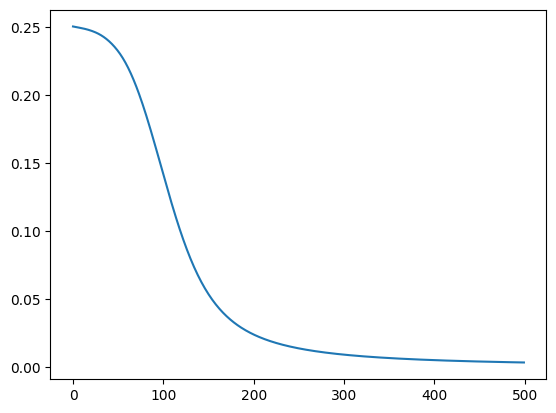

In [411]:
import matplotlib.pyplot as plt
plt.plot(epoch_losses)

In [412]:
eval_dataloader = DataLoader(
    DATASET,
    shuffle=False,
    batch_size=1
)

In [413]:
@torch.no_grad()
def evaluate(dataloader):
    model.eval()

    hits, misses = 0, 0
    for x, y in dataloader:
        y_pred = model(x)
        y_pred = int(round(y_pred.item()))
        match = y == y_pred
        if match: hits += 1
        else: misses += 1
    accuracy = hits / (hits + misses)
    return accuracy

evaluate(eval_dataloader)

1.0